# Exploratory Data Analysis (EDA)

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [21]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("data/bcn_noise_class_ml_subsample.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (11711, 20)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'height', 'betw_centrality', 'clos_centrality', 'green_100', 'straightness', 'closeness400']


## Reduce the number of columns

In [22]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'height', 'betw_centrality', 'clos_centrality', 'green_100', 'straightness', 'closeness400']


<Axes: >

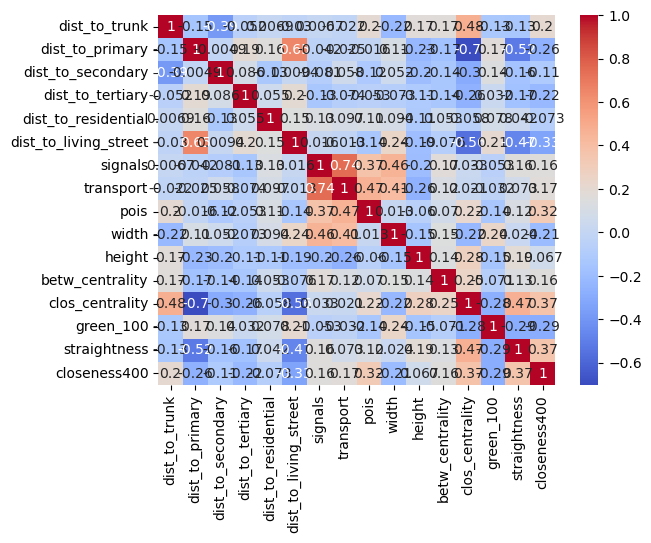

In [23]:
dataset_features = dataset.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night']) #dropping y and non-relevant columns
sns.heatmap(dataset_features.corr(),annot=True, cmap='coolwarm')

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers 

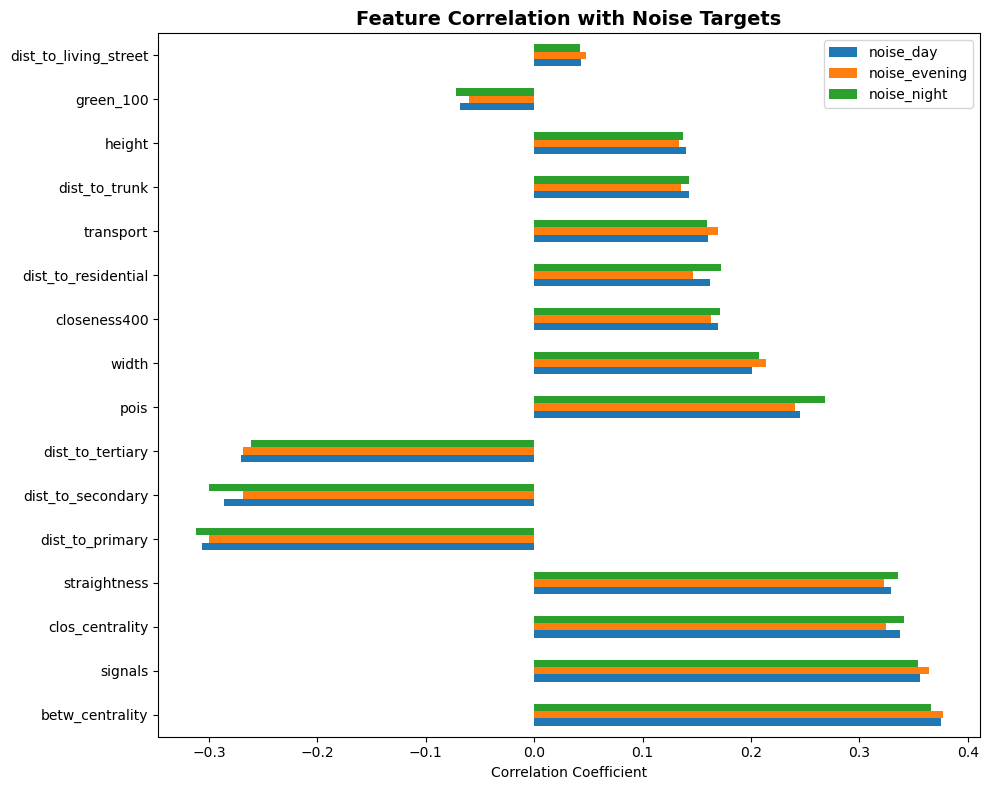

                       noise_day  noise_evening  noise_night
betw_centrality         0.374827       0.376778     0.366425
signals                 0.355871       0.363903     0.353596
clos_centrality         0.337057       0.324295     0.340865
straightness            0.328797       0.322796     0.336034
pois                    0.245039       0.240685     0.268256
width                   0.201243       0.213598     0.207136
closeness400            0.169730       0.163201     0.171160
dist_to_residential     0.161962       0.146246     0.171936
transport               0.160002       0.169797     0.159098
dist_to_trunk           0.143139       0.135570     0.142345
height                  0.139958       0.133677     0.137102
dist_to_living_street   0.043161       0.047487     0.041767
green_100              -0.068625      -0.060172    -0.072639
dist_to_tertiary       -0.270917      -0.268611    -0.261292
dist_to_secondary      -0.286661      -0.268800    -0.300105
dist_to_primary        -

In [24]:
# Extract correlations with noise predictions
dataset_filtered = dataset.drop(columns=['road_id']) #dropping non-relevant columns
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

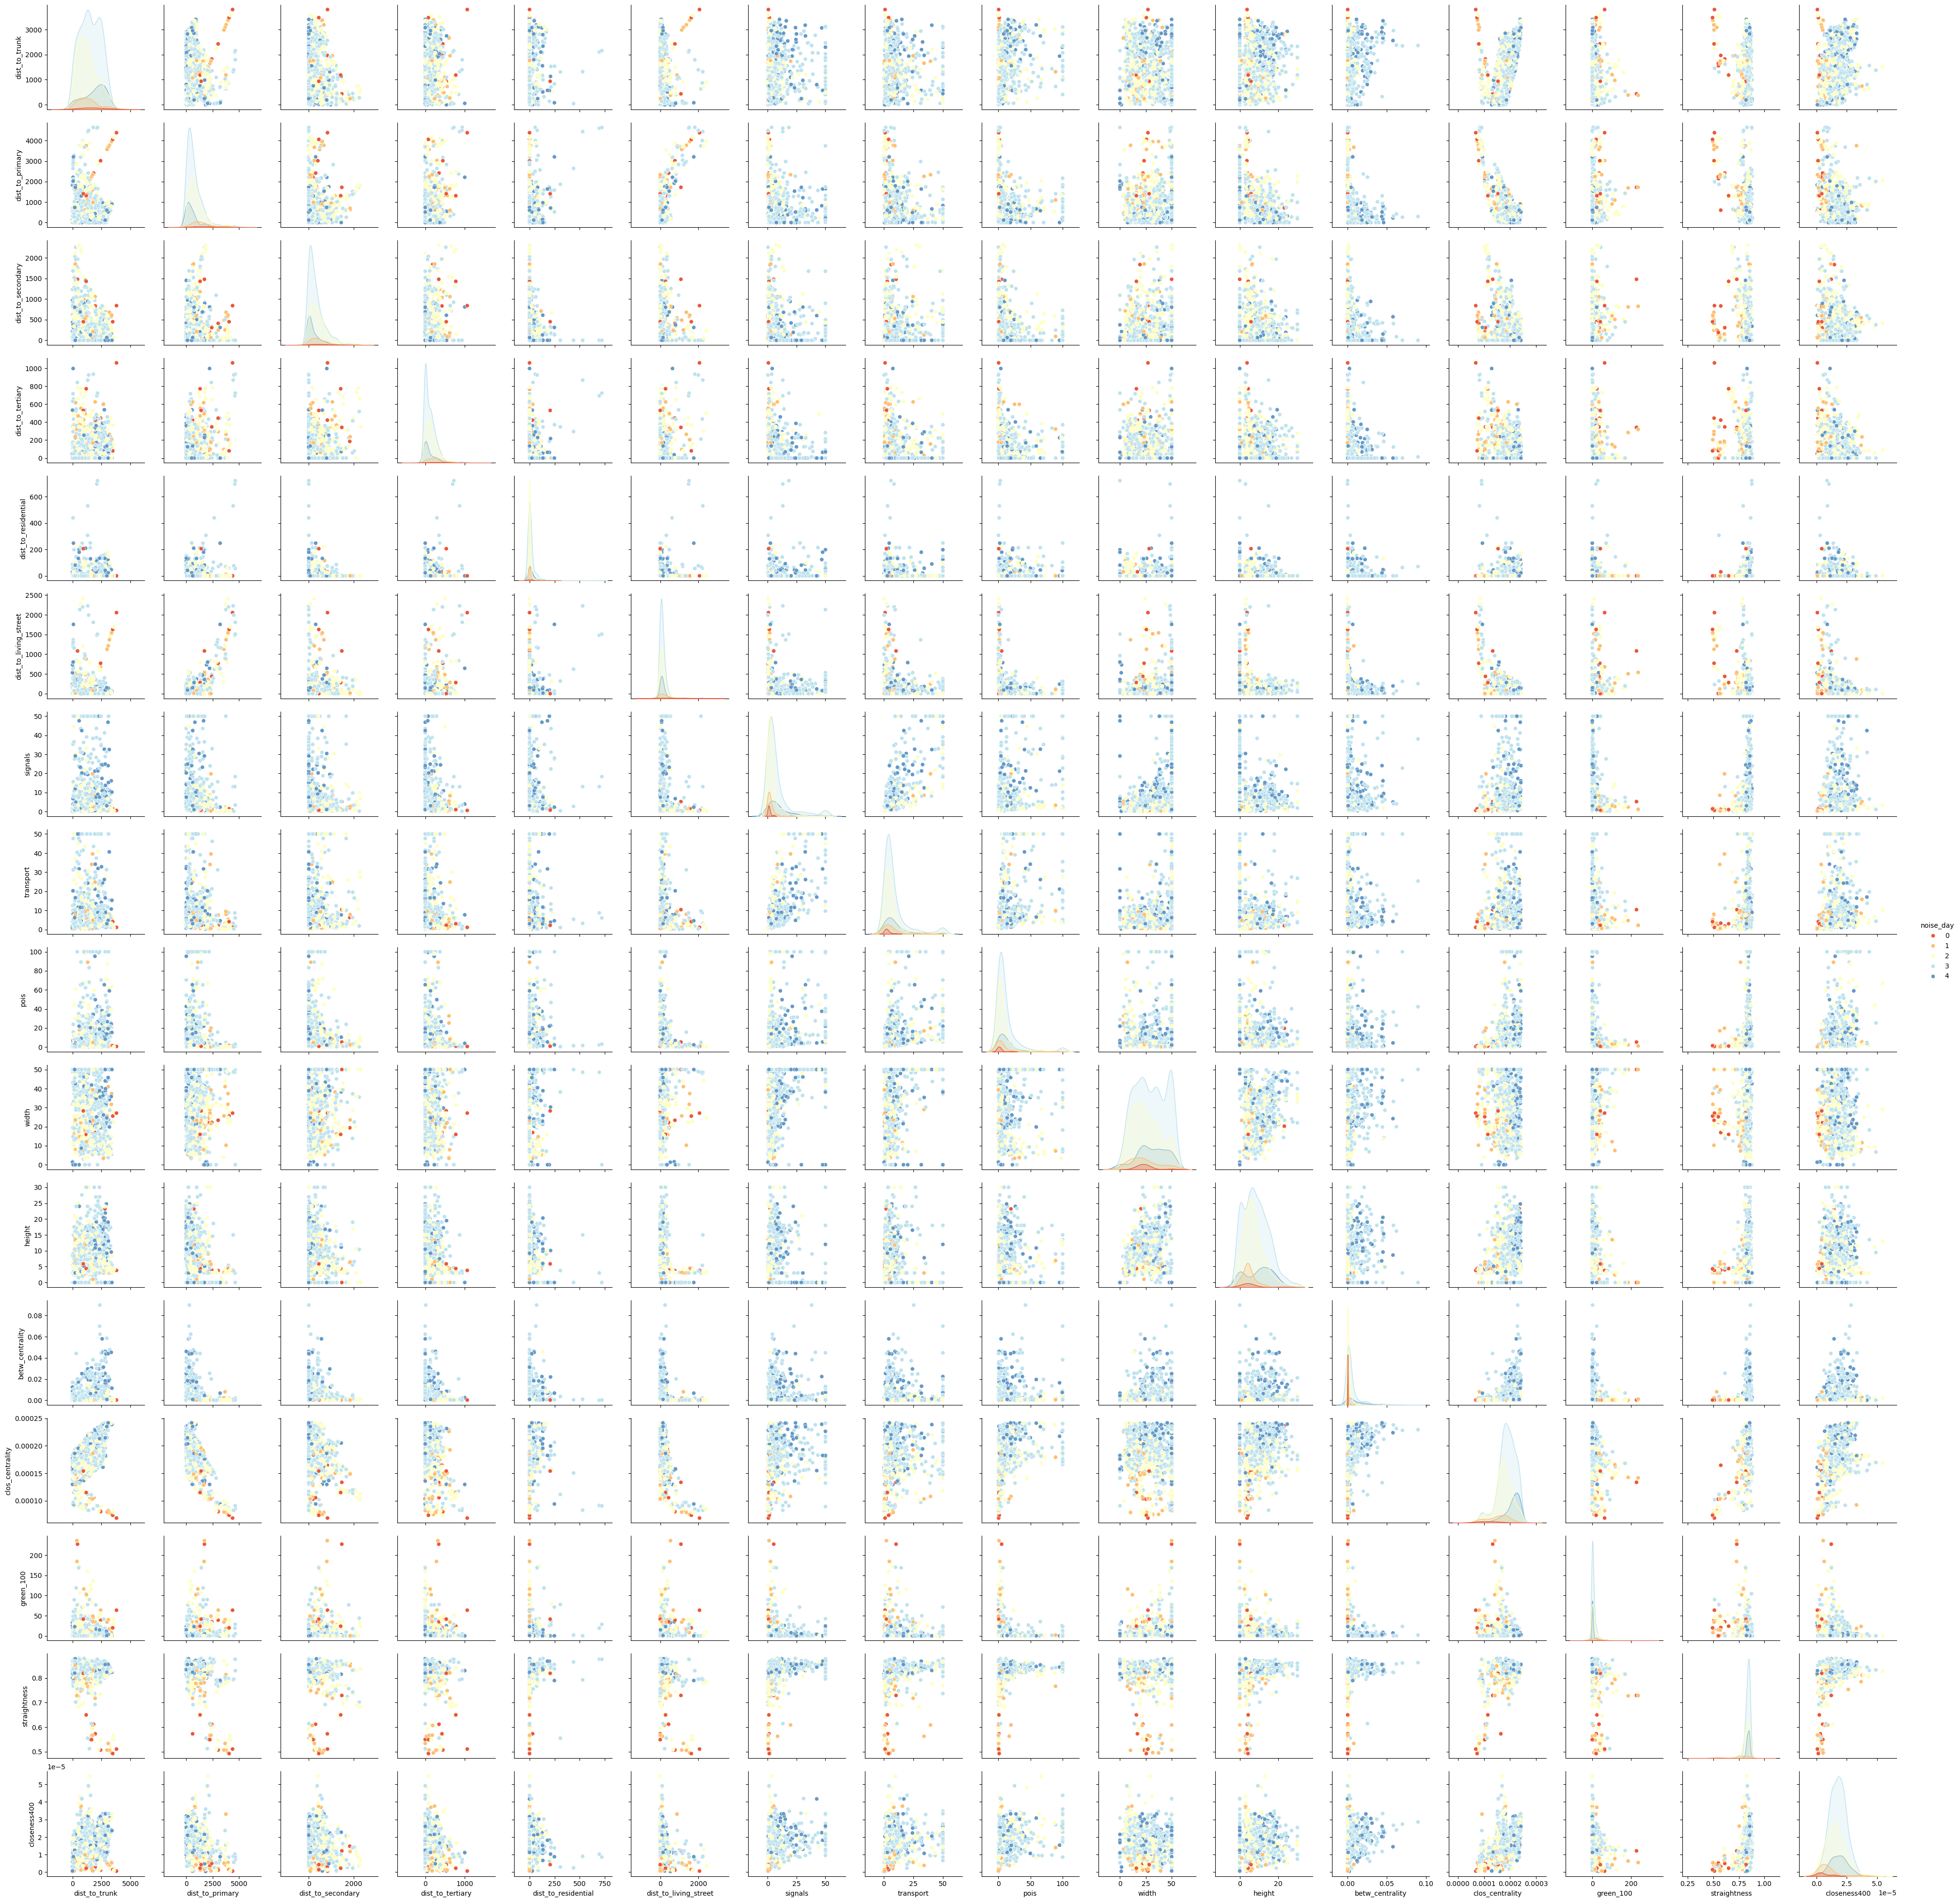

In [25]:
dataset_pairs = dataset.drop(columns=['road_id', 'noise_evening', 'noise_night']) 

# Sample randomly
sample = dataset_pairs.sample(n=1000, random_state=42).copy()

# Get unique noise_day values sorted and convert to ordered categorical
sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

sns.pairplot(sample, hue="noise_day", palette="RdYlBu", corner=False)

In [26]:
# other plots can be
# histograms
# paralel coordinates plot
# boxplots/violonplots for distributions

In [27]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())


Noise Day values:
[2 1 3 4 0]

Unique values count: 5
